Módulo 03: Modelado y Comparación de Clasificadores

1. Carga de Datos y División de ConjuntosCargamos las características generadas y separamos el dataset en entrenamiento y prueba ($80/20$) asegurando la consistencia con una semilla fija.

In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de rutas
base_path = os.getcwd()
PATH_PROCESSED = os.path.join(base_path, "..", "datos_procesados", "reviews_limpias.parquet")

# Cargar dataset
df = pd.read_parquet(PATH_PROCESSED)

# Definir características (X) y variable objetivo (y)
features = ['Score', 'sentiment_score', 'review_len', 'incoherente']
X = df[features]
y = df['y_util']

# División Train/Test con estratificación debido al desbalance de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalado de características (Crucial para Regresión Logística)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Conjunto de prueba: {X_test.shape[0]} muestras")

Conjunto de entrenamiento: 53465 muestras
Conjunto de prueba: 13367 muestras


2. Entrenamiento del Baseline: Regresión Logística
Este modelo nos da la interpretabilidad inicial a través de sus coeficientes.

In [2]:
# Inicializar y entrenar (usando balanceo de peso por el desbalance)
lr_model = LogisticRegression(class_weight='balanced', random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Predicciones
y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print("=== EVALUACIÓN BASELINE: REGRESIÓN LOGÍSTICA ===")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_lr):.4f}\n")

# Mostrar coeficientes (Interpretabilidad)
for feat, coef in zip(features, lr_model.coef_[0]):
    print(f"Característica: {feat:<16} | Coeficiente: {coef:.4f}")

=== EVALUACIÓN BASELINE: REGRESIÓN LOGÍSTICA ===
              precision    recall  f1-score   support

           0       0.62      0.75      0.68      4073
           1       0.88      0.79      0.83      9294

    accuracy                           0.78     13367
   macro avg       0.75      0.77      0.75     13367
weighted avg       0.80      0.78      0.79     13367

ROC-AUC Score: 0.8165

Característica: Score            | Coeficiente: 1.1429
Característica: sentiment_score  | Coeficiente: 0.1296
Característica: review_len       | Coeficiente: 0.2534
Característica: incoherente      | Coeficiente: -0.0220


3. Entrenamiento del Modelo Complejo: LightGBM
Buscamos mayor capacidad predictiva capturando relaciones no lineales entre la longitud del texto y el sentimiento

In [3]:
# Inicializar y entrenar LightGBM
lgb_model = LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train)  # LightGBM no requiere escalado obligatorio

# Predicciones
y_pred_lgb = lgb_model.predict(X_test)
y_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]

print("=== EVALUACIÓN MODELO AVANZADO: LIGHTGBM ===")
print(classification_report(y_test, y_pred_lgb))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_lgb):.4f}")

=== EVALUACIÓN MODELO AVANZADO: LIGHTGBM ===
              precision    recall  f1-score   support

           0       0.61      0.80      0.69      4073
           1       0.90      0.78      0.83      9294

    accuracy                           0.78     13367
   macro avg       0.75      0.79      0.76     13367
weighted avg       0.81      0.78      0.79     13367

ROC-AUC Score: 0.8453


4. Comparación de Curvas ROC
Visualizamos el rendimiento global de ambos modelos para tomar la decisión de negocio.

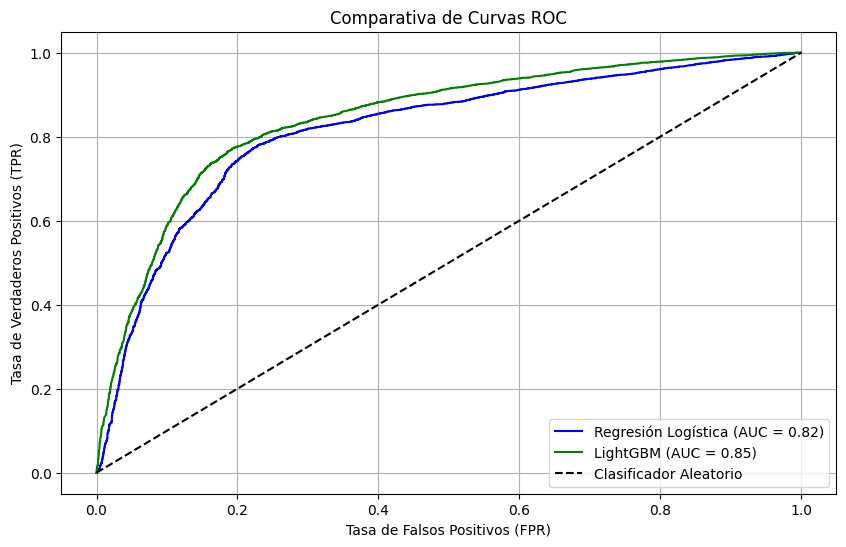

In [4]:
# Calcular curvas ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_proba_lgb)

plt.figure(figsize=(10, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Regresión Logística (AUC = {roc_auc_score(y_test, y_proba_lr):.2f})', color='blue')
plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC = {roc_auc_score(y_test, y_proba_lgb):.2f})', color='green')
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio')

plt.title('Comparativa de Curvas ROC')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [6]:
import joblib
import os

# Definir la ruta correcta dentro de la nueva carpeta
base_path = os.getcwd()
MODEL_EXPORT_PATH = os.path.join(base_path, "..", "modelos", "modelo_lgb.joblib")

# Guardar el modelo LightGBM entrenado
joblib.dump(lgb_model, MODEL_EXPORT_PATH)
print(f"¡Modelo guardado exitosamente en: {MODEL_EXPORT_PATH}!")

¡Modelo guardado exitosamente en: c:\Users\Eduardo\Desktop\UNIANDES\Seminario\Predictivo\cuadernos\..\modelos\modelo_lgb.joblib!


Código para el Método del Codo

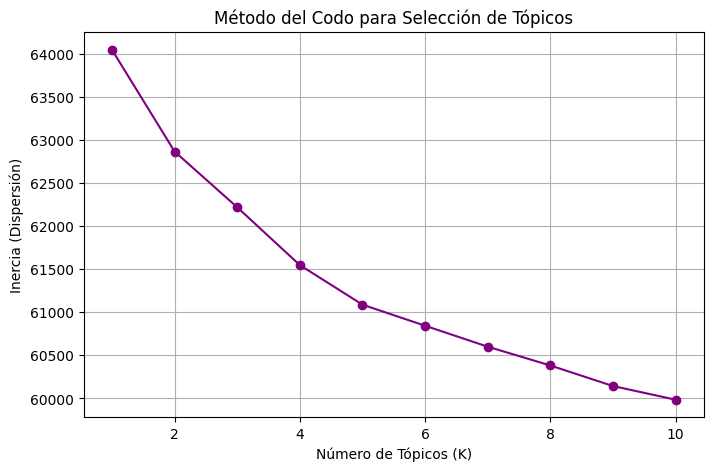

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Transformar el texto a una matriz numérica (TF-IDF)
tfidf = TfidfVectorizer(max_features=1000, stop_words='english')
X_tfidf = tfidf.fit_transform(df['Text'])

# 2. Calcular la inercia para K de 1 a 10
inercias = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_tfidf)
    inercias.append(kmeans.inertia_)

# 3. Graficar los resultados
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inercias, marker='o', color='purple')
plt.title('Método del Codo para Selección de Tópicos')
plt.xlabel('Número de Tópicos (K)')
plt.ylabel('Inercia (Dispersión)')
plt.grid(True)
plt.show()

Para que el modelo guarde esta relación de categorías en el archivo que usará la API, debemos añadir la asignación al dataset. Corre esta celda en tu cuaderno justo después de graficar el codo

In [9]:
# Suponiendo que elegimos K=5 según el gráfico del codo
K_OPTIMO = 5
kmeans_final = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)

# Asignar a cada reseña su tópico
df['resena_topic'] = kmeans_final.fit_predict(X_tfidf)

# Encontrar el tópico predominante por cada Producto (La categoría real del producto)
producto_contexto = df.groupby('ProductId')['resena_topic'].agg(lambda x: x.mode()[0]).reset_index()
producto_contexto.columns = ['ProductId', 'product_topic']

# Guardar esta matriz de contexto para que la API la consulte en milisegundos
producto_contexto.to_parquet("../datos_procesados/productos_contexto.parquet")
print("¡Contexto semántico de productos guardado con éxito para la API!")

¡Contexto semántico de productos guardado con éxito para la API!


De dónde sacamos los nombres?
Dado que no tenemos una base de datos externa con el catálogo de Amazon, la forma más limpia y profesional de conseguir el nombre del producto es extrayéndolo directamente de los textos de las reseñas históricas

In [10]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
import os

# 1. Cargar tus datos limpios
df = pd.read_parquet('../datos_procesados/reviews_limpias.parquet')

# 2. Agrupar todo el texto por cada producto
productos_texto = df.groupby('ProductId')['Text'].agg(lambda x: ' '.join(x)).reset_index()

# 3. Función para extraer las 3 palabras clave más repetidas de cada producto
def extraer_nombre(texto):
    try:
        # Buscamos combinaciones de 2 o 3 palabras (ej: "green tea", "dog food")
        vec = CountVectorizer(ngram_range=(2, 3), max_features=1, stop_words='english')
        vec.fit([texto])
        return vec.get_feature_names_out()[0].title()
    except:
        return "Producto Alimenticio General"

# 4. Crear la columna con el nombre comercial automático
productos_texto['ProductName'] = productos_texto['Text'].apply(extraer_nombre)

# 5. Unir con el archivo de contexto que ya tenías creado antes
CONTEXT_PATH = "../datos_procesados/productos_contexto.parquet"
df_contexto_existente = pd.read_parquet(CONTEXT_PATH)

# Combinar los tópicos con los nuevos nombres
df_contexto_final = pd.merge(df_contexto_existente, productos_texto[['ProductId', 'ProductName']], on='ProductId', how='left')

# Guardar el archivo actualizado
df_contexto_final.to_parquet(CONTEXT_PATH)
print("¡Nombres comerciales generados y acoplados al contexto con éxito!")

¡Nombres comerciales generados y acoplados al contexto con éxito!
